In [ ]:
!pip install statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('/content/kenya_inflation.csv')

In [ ]:
df.head(10)

,Year,CPI
0,1960,1.243781
1,1961,2.457002
2,1962,3.117506
3,1963,0.697674
4,1964,-0.099305
5,1965,3.578529
6,1966,5.014395
7,1967,1.759196
8,1968,0.366712
9,1969,-0.171501


In [ ]:
df.tail()

,Year,CPI
59,2019,5.239638
60,2020,5.405162
61,2021,6.107936
62,2022,7.659863
63,2023,7.671396


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    64 non-null     int64  
 1   CPI     64 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [ ]:
df.describe()

,Year,CPI
count,64.000000,64.000000
mean,1991.500000,9.783926
std,18.618987,8.015971
min,1960.000000,-0.171501
25%,1975.750000,4.933248
50%,1991.500000,8.321661
75%,2007.250000,12.450364
max,2023.000000,45.978881


Text(0, 0.5, 'CPI')

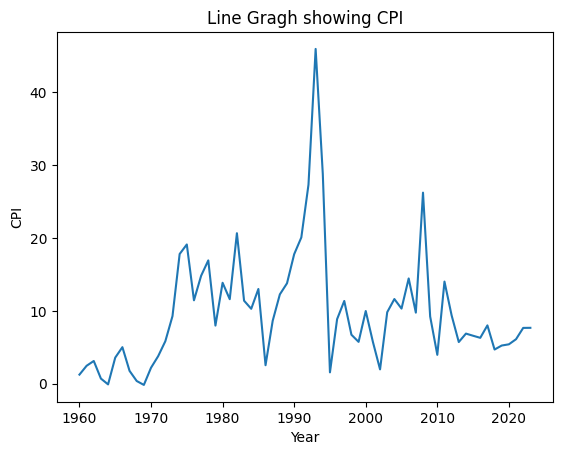

In [ ]:
## Time series i.e. since this is a time series data , we'll have a line gragh to show trend.
## Well use ARIMA model
plt.plot(df['Year'],df['CPI'])
plt.title('Line Gragh showing CPI')
plt.xlabel('Year')
plt.ylabel('CPI')

Text(0, 0.5, 'CPI')

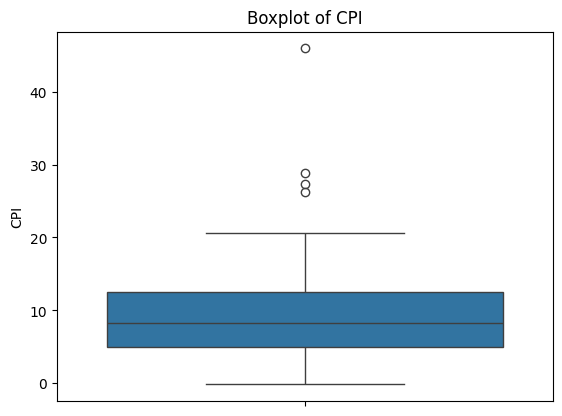

In [ ]:
sns.boxplot(y=df['CPI'])
plt.title('Boxplot of CPI')
plt.ylabel('CPI')

In [ ]:
## For ARIMA, we dont have to remove the outliers.
Series=df['CPI']

In [ ]:
## Train
train_size=int(len(Series)*0.8)
train=Series[:train_size]
test=Series[train_size:]

In [ ]:
##Call the ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
## Build model
model=ARIMA(train, order=(1,1,1))

In [ ]:
## Fit the model
model_fit=model.fit()

In [ ]:
## Forcast
forcast=model_fit.forecast(steps=len(test))

In [ ]:
## Model Evaluation
mse=mean_squared_error(test,forcast)
print("mse", mse)

mse 19.54389033735476


In [ ]:
print(forcast)

51     6.759806
52     8.418523
53     9.401702
54     9.984465
55    10.329889
56    10.534634
57    10.655993
58    10.727927
59    10.770564
60    10.795837
61    10.810817
62    10.819696
63    10.824959
Name: predicted_mean, dtype: float64


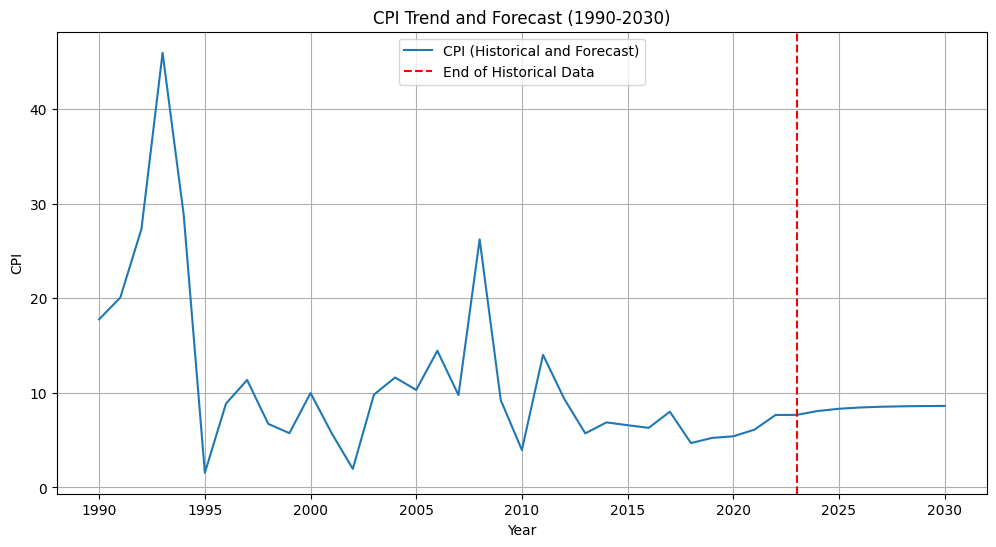

In [ ]:
import numpy as np

# 1. Filter historical data from 1990
df_plot_historical = df[df['Year'] >= 1990].copy()

# 2. Train a new ARIMA model on the entire Series (df['CPI'])
#    Use the 'Series' variable which holds df['CPI']
model_full = ARIMA(Series, order=(1,1,1))
model_full_fit = model_full.fit()

# 3. Generate future years (from the year after the last historical data up to 2030)
last_historical_year = df['Year'].max() # 2023
future_years_range = np.arange(last_historical_year + 1, 2030 + 1) # 2024, ..., 2030

# 4. Forecast CPI for these future years
forecast_steps = len(future_years_range)
forecast_values = model_full_fit.forecast(steps=forecast_steps)

# 5. Create a DataFrame for the future forecast
df_forecast = pd.DataFrame({'Year': future_years_range, 'CPI': forecast_values.values})

# 6. Combine historical and forecasted data for plotting
combined_df = pd.concat([df_plot_historical, df_forecast]).set_index('Year')

# 7. Plot the line graph
plt.figure(figsize=(12, 6))
plt.plot(combined_df['CPI'], label='CPI (Historical and Forecast)')
plt.axvline(x=last_historical_year, color='r', linestyle='--', label='End of Historical Data')
plt.title('CPI Trend and Forecast (1990-2030)')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.legend()
plt.grid(True)
plt.show()